In [ ]:
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = load_iris(as_frame=True)

X = iris.data.iloc[:,2:].to_numpy()
y= iris.target == 2

pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('svc', LinearSVC())
])

pipeline.fit(X,y)

,steps,"[('scale', ...), ('svc', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001


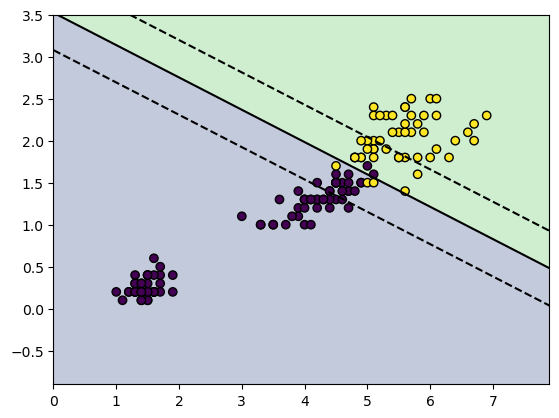

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# 범위 설정
x0_min, x0_max = X[:, 0].min()-1, X[:,0].max()+1
x1_min, x1_max = X[:, 1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x0_min, x0_max, 500),
    np.linspace(x1_min, x1_max, 500)
)
grid = np.c_[xx.ravel(), yy.ravel()]

z = pipeline.predict(grid)
z = z.reshape(xx.shape)

plt.contourf(xx,yy,z, alpha=0.3)  # 결정영역
plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')

# 결정 경계
decision = pipeline.decision_function(grid)
decision = decision.reshape(xx.shape)
plt.contour(
    xx, yy, decision, levels = [-1, 0, 1],
    linestyles = ['--', '-', '--'],
    colors='k'
)

plt.show()


In [40]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import SGDClassifier, LogisticRegression
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

# X, y = make_moons(n_samples=100, noise=0.15, random_state=42)
# plt.scatter(X[:, 0], X[:,1], c=y)

# 분류 모델
lr = LogisticRegression()
sdg = SGDClassifier(random_state=42)

# 파이프라인 만들어서 모델 학습, 예측값, f-1 score
models = {'lr' : LogisticRegression(random_state=42), 'sgd': SGDClassifier(random_state=42)}

for label, model in models.items():
    pipeline = Pipeline([
        ('scale', StandardScaler()),
        (label, model)
    ])
    pipeline.fit(X, y)
    predict = pipeline.predict(X)
    print( classification_report(y, predict) )




              precision    recall  f1-score   support

           0       0.86      0.86      0.86        50
           1       0.86      0.86      0.86        50

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.86      0.86      0.86       100

              precision    recall  f1-score   support

           0       0.84      0.92      0.88        50
           1       0.91      0.82      0.86        50

    accuracy                           0.87       100
   macro avg       0.87      0.87      0.87       100
weighted avg       0.87      0.87      0.87       100



In [ ]:
# svm 적용
from sklearn.svm import SVC
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    # ('svc', SVC(kernel='poly', degree=3, C=7, coef0=1))
    ('svc', SVC(kernel='rbf'))
])

pipeline.fit(X,y)
predict = pipeline.predict(X)
print(classification_report(y, predict))

              precision    recall  f1-score   support

           0       0.92      0.96      0.94        50
           1       0.96      0.92      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



In [88]:
# 와인 품질 분휴
from sklearn.datasets import load_wine
# LinearSVC => 선형
from sklearn.svm import SVC, LinearSVC
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split



wine = load_wine(as_frame=True)

wine.frame.head()

X = wine.frame.drop(columns='target')
y = wine.frame['target']

x_train,x_test,y_train,y_test = train_test_split(X, y, train_size=0.2, random_state=42, stratify=y)

models = {'lr_svc':LinearSVC(), 'svc':SVC(), 
          'lr' : LogisticRegression(), 'sgd': SGDClassifier()}

for k, model in models.items():
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        (k, model)
    ])
    pipeline.fit(x_train,y_train)
    y_pred = pipeline.predict(x_test)
    print(f"model : {k}")
    print(classification_report(y_test, y_pred))



model : lr_svc
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        47
           1       1.00      0.89      0.94        57
           2       0.91      1.00      0.95        39

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143

model : svc
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        47
           1       0.98      0.96      0.97        57
           2       0.95      0.97      0.96        39

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143

model : lr
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        47
           1       1.00      0.89      0.94        57
           2       0.91      1.00    

<Axes: >

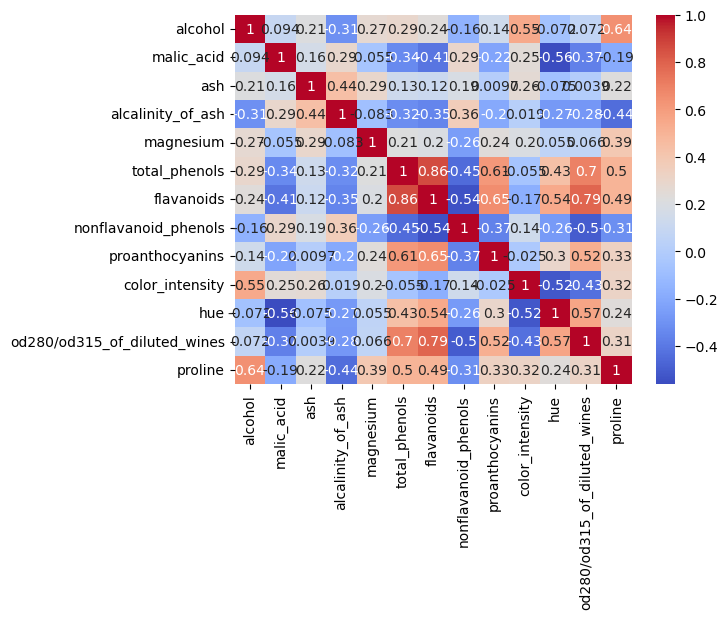

In [93]:
# 와인 품질 분휴
from sklearn.datasets import load_wine
# LinearSVC => 선형
from sklearn.svm import SVC, LinearSVC
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

wine = load_wine(as_frame=True)

import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(data=wine.data.corr(), annot=True, cmap='coolwarm')